# Lab 04: MNIST Handwritten Digit Classification using Deep MLP

This notebook implements and analyzes Deep Feedforward Neural Networks (MLP) on MNIST **without using CNNs**.

## Workflow
1. Setup and imports
2. Dataset loading and exploration
3. Preprocessing
4. Baseline model
5. Deep model
6. Overfitting study
7. Regularization study
8. Hyperparameter tuning
9. Optimizer comparison
10. Results summary and analysis

In [2]:
# Step 1: Setup and imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


## Step 2: Load and Explore MNIST Dataset

Training samples: 60000
Test samples: 10000
Image shape: (28, 28) (28x28)
Number of classes: 10


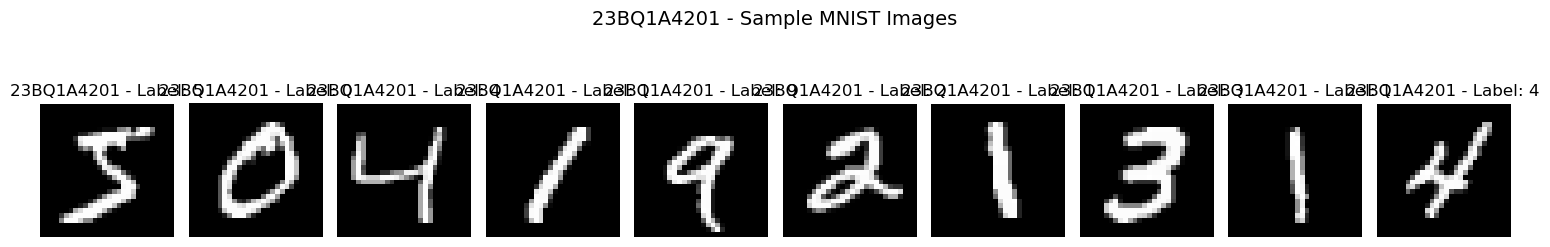

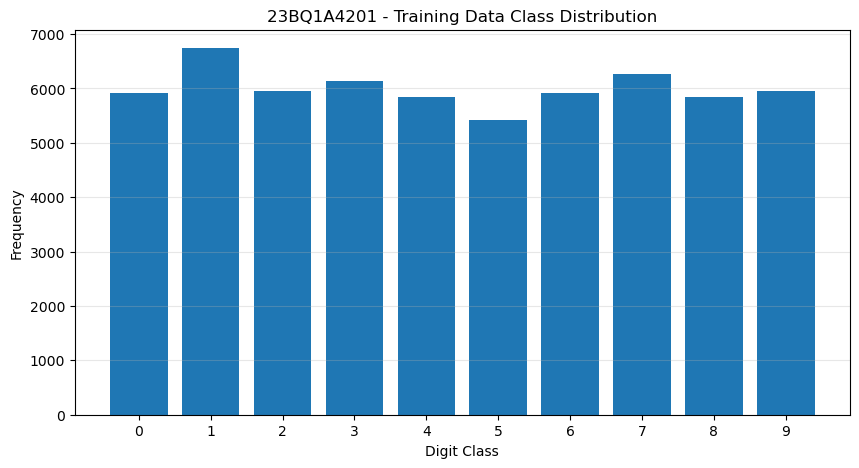

In [3]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Image shape: {X_train.shape[1:]} (28x28)")
print(f"Number of classes: {len(np.unique(y_train))}")

# Visualize sample images
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"23BQ1A4201 - Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle('23BQ1A4201 - Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar(unique, counts)
plt.xlabel('Digit Class')
plt.ylabel('Frequency')
plt.title('23BQ1A4201 - Training Data Class Distribution')
plt.xticks(unique)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Step 3: Data Preprocessing

In [4]:
# Flatten images: (28, 28) -> (784,)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Normalize pixel values: [0, 255] -> [0, 1]
X_train_norm = X_train_flat / 255.0
X_test_norm = X_test_flat / 255.0

# One-hot encode labels
y_train_encoded = keras.utils.to_categorical(y_train, 10)
y_test_encoded = keras.utils.to_categorical(y_test, 10)

# Train-validation split
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_norm,
    y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test_norm shape: {X_test_norm.shape}")
print(f"y_train_final shape: {y_train_final.shape}")

X_train_final shape: (48000, 784)
X_val shape: (12000, 784)
X_test_norm shape: (10000, 784)
y_train_final shape: (48000, 10)


## Step 4: Experiment 1 - Baseline MLP (784 → 512 → 256 → 10)

In [5]:
def create_baseline_model():
    model = Sequential([
        Dense(512, activation='relu', input_shape=(784,), name='hidden1'),
        Dense(256, activation='relu', name='hidden2'),
        Dense(10, activation='softmax', name='output')
    ])
    return model

# Parameter calculation (manual)
params_layer1 = (784 * 512) + 512
params_layer2 = (512 * 256) + 256
params_output = (256 * 10) + 10
total_params = params_layer1 + params_layer2 + params_output

print(f"Layer 1 parameters: {params_layer1:,}")
print(f"Layer 2 parameters: {params_layer2:,}")
print(f"Output layer parameters: {params_output:,}")
print(f"Total parameters: {total_params:,}")

baseline_model = create_baseline_model()
baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
baseline_model.summary()

history_baseline = baseline_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)

test_loss, test_accuracy = baseline_model.evaluate(X_test_norm, y_test_encoded, verbose=0)
print(f"\nBaseline Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Baseline Test Loss: {test_loss:.4f}")

Layer 1 parameters: 401,920
Layer 2 parameters: 131,328
Output layer parameters: 2,570
Total parameters: 535,818


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9272 - loss: 0.2486 - val_accuracy: 0.9602 - val_loss: 0.1306
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9731 - loss: 0.0901 - val_accuracy: 0.9627 - val_loss: 0.1276
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9825 - loss: 0.0561 - val_accuracy: 0.9693 - val_loss: 0.1066
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9882 - loss: 0.0376 - val_accuracy: 0.9699 - val_loss: 0.1012
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9909 - loss: 0.0281 - val_accuracy: 0.9758 - val_loss: 0.0923
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9928 - loss: 0.0222 - val_accuracy: 0.9772 - val_loss: 0.0879
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9951 - loss: 0.0151 - val_accuracy: 0.9746 - val_loss: 0.1089
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9951 - loss: 0.0153 - val_accura

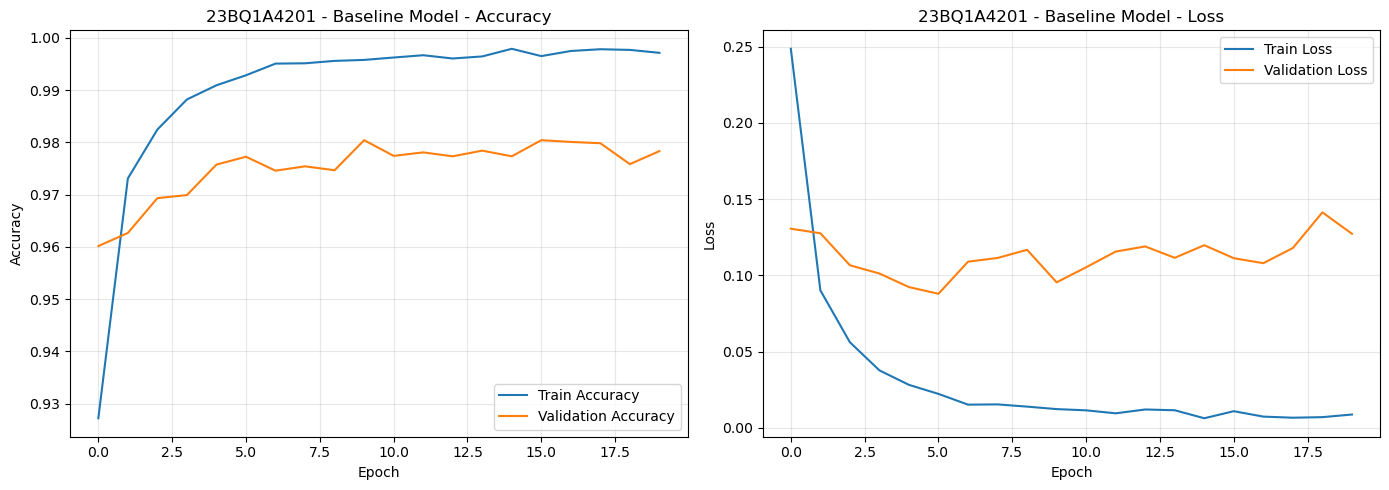

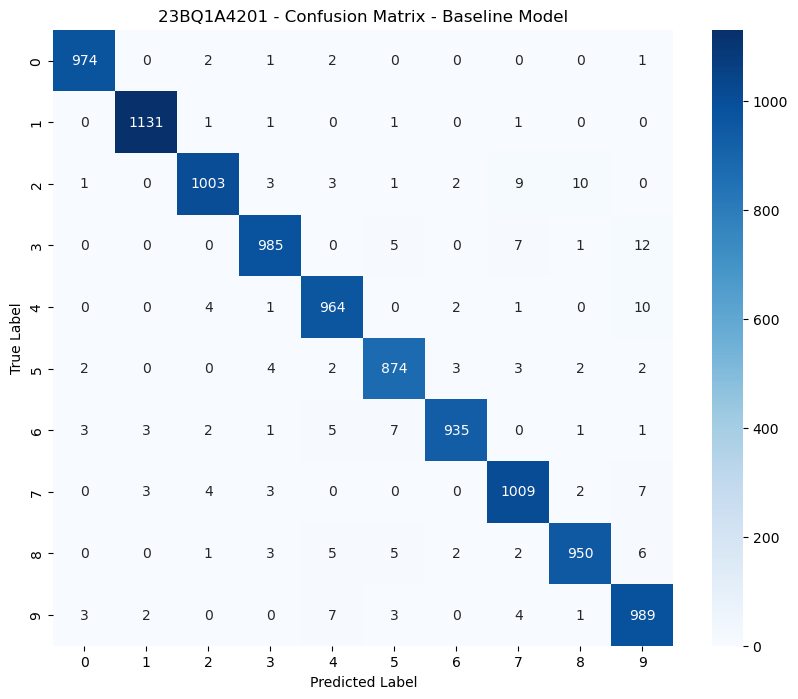


Classification Report - Baseline Model:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [6]:
def plot_history(history, title='Model Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'23BQ1A4201 - {title} - Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title(f'23BQ1A4201 - {title} - Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_baseline, 'Baseline Model')

# Confusion matrix and classification report
y_pred_baseline = baseline_model.predict(X_test_norm, verbose=0)
y_pred_classes = np.argmax(y_pred_baseline, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('23BQ1A4201 - Confusion Matrix - Baseline Model')
plt.show()

print('\nClassification Report - Baseline Model:')
print(classification_report(y_test, y_pred_classes, target_names=[str(i) for i in range(10)]))

## Step 5: Experiment 2 - Deep Network (4 hidden layers)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,050 (2.19 MB)

 Trainable params: 575,050 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9206 - loss: 0.2704 - val_accuracy: 0.9591 - val_loss: 0.1430
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9703 - loss: 0.0960 - val_accuracy: 0.9645 - val_loss: 0.1241
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9807 - loss: 0.0644 - val_accuracy: 0.9678 - val_loss: 0.1245
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9846 - loss: 0.0462 - val_accuracy: 0.9664 - val_loss: 0.1270
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9878 - loss: 0.0373 - val_accuracy: 0.9712 - val_loss: 0.1105
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9902 - loss: 0.0302 - val_accuracy: 0.9747 - val_loss: 0.1038
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9912 - loss: 0.0256 - val_accuracy: 0.9738 - val_loss: 0.1170
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9926 - loss: 0.0219 - val_accu

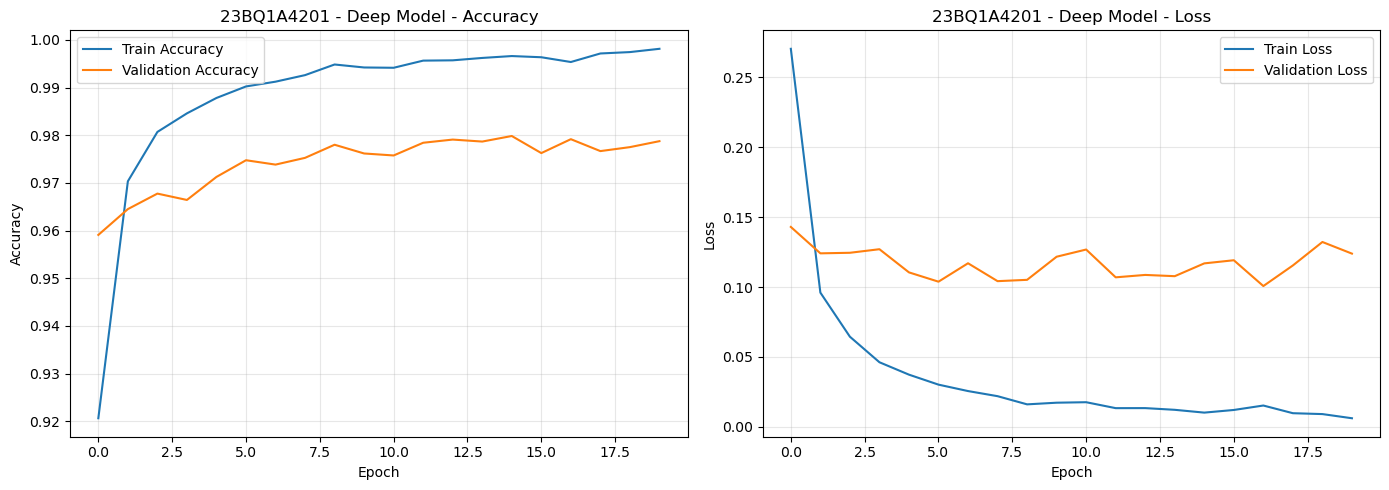

In [7]:
def create_deep_model():
    model = Sequential([
        Dense(512, activation='relu', input_shape=(784,), name='hidden1'),
        Dense(256, activation='relu', name='hidden2'),
        Dense(128, activation='relu', name='hidden3'),
        Dense(64, activation='relu', name='hidden4'),
        Dense(10, activation='softmax', name='output')
    ])
    return model

deep_model = create_deep_model()
deep_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

deep_model.summary()
history_deep = deep_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)

test_loss_deep, test_accuracy_deep = deep_model.evaluate(X_test_norm, y_test_encoded, verbose=0)
print(f"\nDeep Model Test Accuracy: {test_accuracy_deep*100:.2f}%")
print(f"Deep Model Test Loss: {test_loss_deep:.4f}")

plot_history(history_deep, 'Deep Model')

## Step 6: Experiment 3 - Overfitting Study (No Dropout)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9319 - loss: 0.2243 - val_accuracy: 0.9634 - val_loss: 0.1222
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9742 - loss: 0.0825 - val_accuracy: 0.9668 - val_loss: 0.1166
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9829 - loss: 0.0543 - val_accuracy: 0.9584 - val_loss: 0.1613
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9851 - loss: 0.0438 - val_accuracy: 0.9675 - val_loss: 0.1215
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9899 - loss: 0.0313 - val_accuracy: 0.9700 - val_loss: 0.1216
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9905 - loss: 0.0284 - val_accuracy: 0.9778 - val_loss: 0.0992
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9929 - loss: 0.0226 - val_accuracy: 0.9778 - val_loss: 0.1049
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9931 - loss: 0.0203 - val_acc

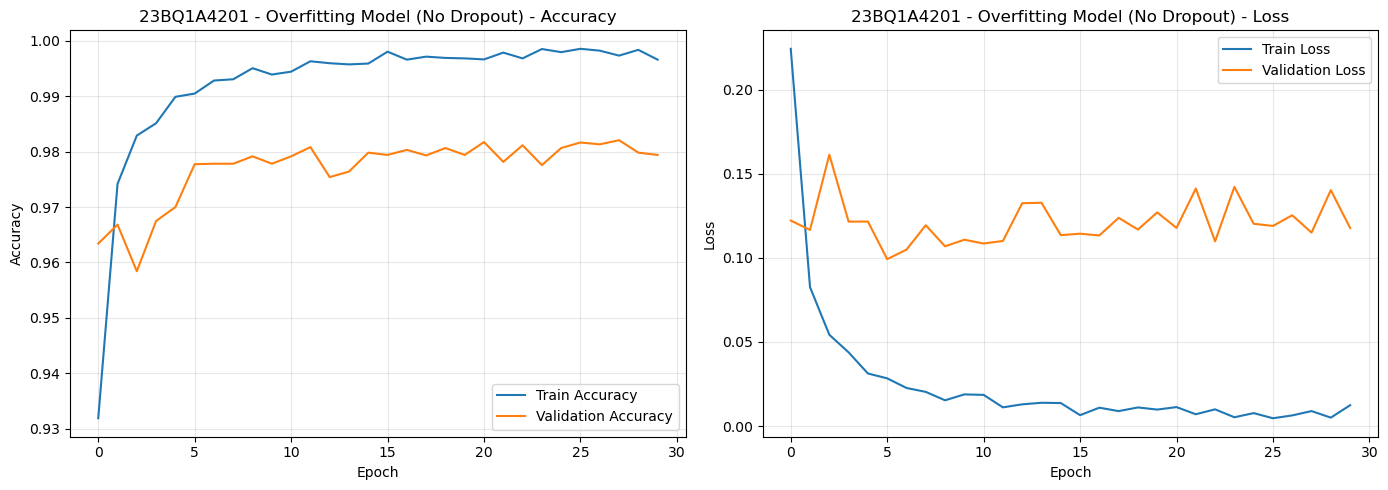

In [8]:
def create_overfit_model():
    model = Sequential([
        Dense(1024, activation='relu', input_shape=(784,), name='hidden1'),
        Dense(512, activation='relu', name='hidden2'),
        Dense(256, activation='relu', name='hidden3'),
        Dense(10, activation='softmax', name='output')
    ])
    return model

overfit_model = create_overfit_model()
overfit_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_overfit = overfit_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    verbose=1
)

overfit_loss, overfit_accuracy = overfit_model.evaluate(X_test_norm, y_test_encoded, verbose=0)
print(f"\nOverfit Model Test Accuracy: {overfit_accuracy*100:.2f}%")

final_train_acc = history_overfit.history['accuracy'][-1]
final_val_acc = history_overfit.history['val_accuracy'][-1]
print(f"Final Training Accuracy: {final_train_acc*100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc*100:.2f}%")
print(f"Overfitting Gap: {(final_train_acc - final_val_acc)*100:.2f}%")

plot_history(history_overfit, 'Overfitting Model (No Dropout)')

## Step 7: Experiment 4 - Regularization Study (Dropout, L2, EarlyStopping)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8802 - loss: 0.3897 - val_accuracy: 0.9525 - val_loss: 0.1574
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9529 - loss: 0.1600 - val_accuracy: 0.9634 - val_loss: 0.1254
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9659 - loss: 0.1159 - val_accuracy: 0.9705 - val_loss: 0.1062
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9709 - loss: 0.0961 - val_accuracy: 0.9753 - val_loss: 0.0890
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9768 - loss: 0.0787 - val_accuracy: 0.9749 - val_loss: 0.0910
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9790 - loss: 0.0695 - val_accuracy: 0.9777 - val_loss: 0.0865
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9801 - loss: 0.0619 - val_accuracy: 0.9781 - val_loss: 0.0857
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9819 - loss: 0.0566 - val_accu

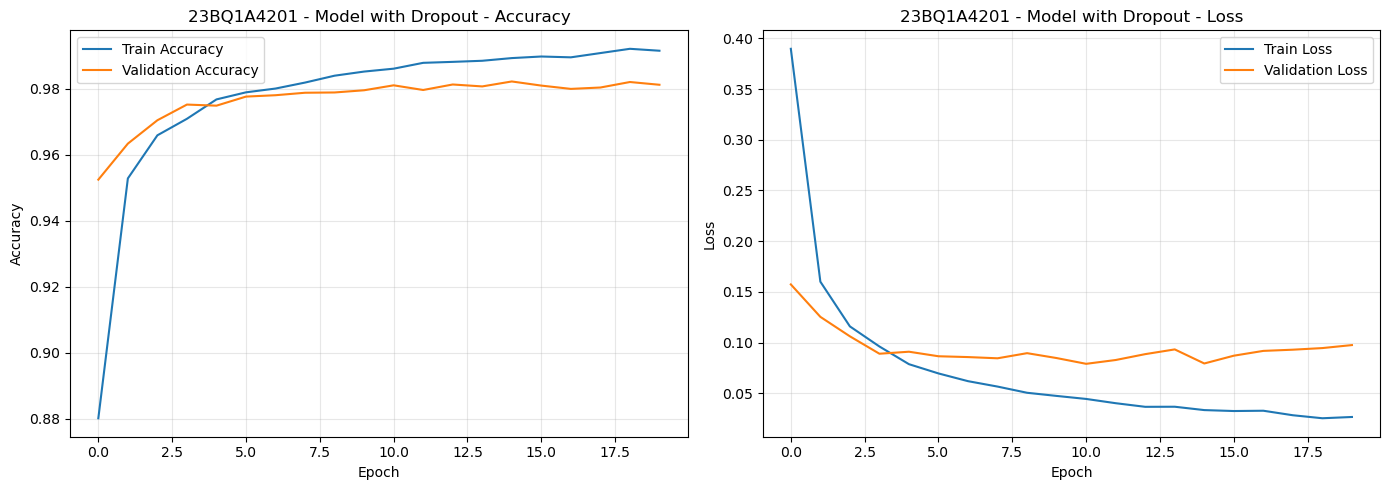

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9168 - loss: 0.8098 - val_accuracy: 0.9506 - val_loss: 0.5213
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9596 - loss: 0.4077 - val_accuracy: 0.9644 - val_loss: 0.3473
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9676 - loss: 0.3009 - val_accuracy: 0.9645 - val_loss: 0.2948
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9726 - loss: 0.2513 - val_accuracy: 0.9640 - val_loss: 0.2672
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9747 - loss: 0.2268 - val_accuracy: 0.9678 - val_loss: 0.2449
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9767 - loss: 0.2095 - val_accuracy: 0.9672 - val_loss: 0.2346
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9784 - loss: 0.1956 - val_accuracy: 0.9687 - val_loss: 0.2255
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9801 - loss: 0.1862 - val_accu

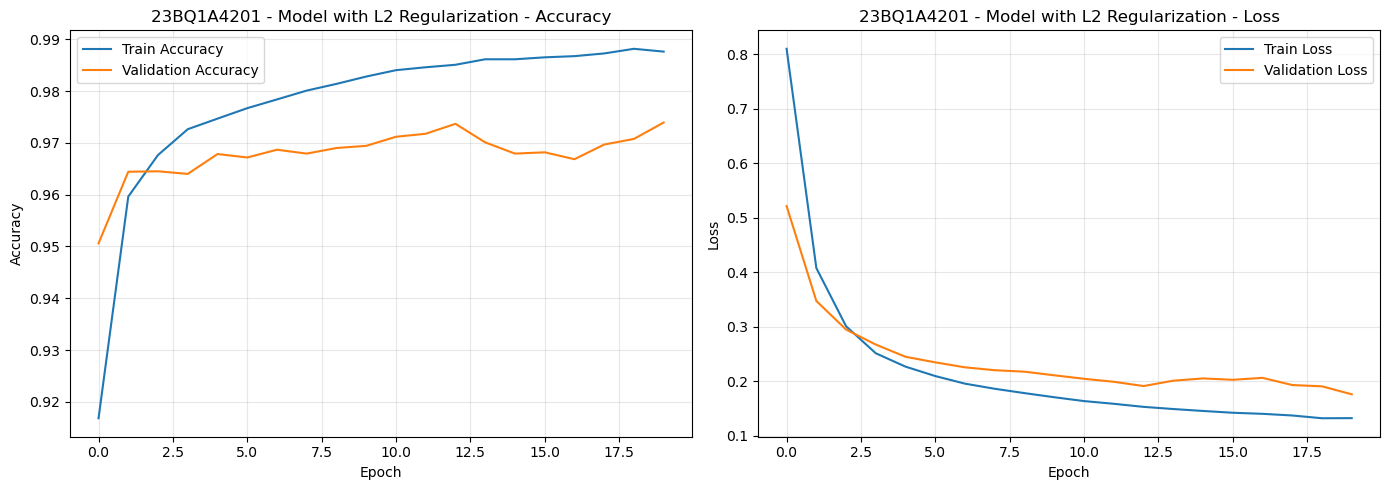

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8609 - loss: 1.0779 - val_accuracy: 0.9513 - val_loss: 0.6080
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9387 - loss: 0.5661 - val_accuracy: 0.9599 - val_loss: 0.4275
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9502 - loss: 0.4270 - val_accuracy: 0.9650 - val_loss: 0.3422
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9543 - loss: 0.3684 - val_accuracy: 0.9657 - val_loss: 0.3129
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9556 - loss: 0.3406 - val_accuracy: 0.9688 - val_loss: 0.2957
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9570 - loss: 0.3299 - val_accuracy: 0.9700 - val_loss: 0.2872
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9594 - loss: 0.3164 - val_accuracy: 0.9673 - val_loss: 0.2871
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9577 - loss: 0.3199 - val_accu

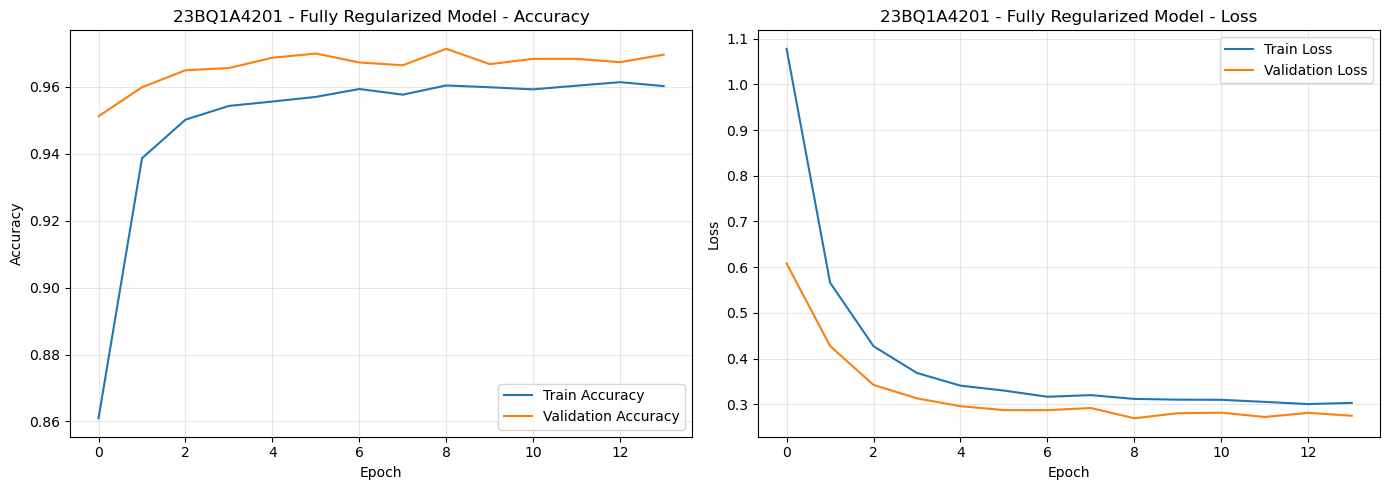

In [9]:
def create_dropout_model():
    model = Sequential([
        Dense(512, activation='relu', input_shape=(784,), name='hidden1'),
        Dropout(0.3),
        Dense(256, activation='relu', name='hidden2'),
        Dropout(0.3),
        Dense(128, activation='relu', name='hidden3'),
        Dropout(0.3),
        Dense(10, activation='softmax', name='output')
    ])
    return model

def create_l2_model():
    model = Sequential([
        Dense(512, activation='relu', kernel_regularizer=l2(0.001), input_shape=(784,)),
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(10, activation='softmax')
    ])
    return model

def create_regularized_model():
    model = Sequential([
        Dense(512, activation='relu', kernel_regularizer=l2(0.001), input_shape=(784,)),
        Dropout(0.4),
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.4),
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        Dense(10, activation='softmax')
    ])
    return model

# Dropout model
dropout_model = create_dropout_model()
dropout_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_dropout = dropout_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)
dropout_loss, dropout_accuracy = dropout_model.evaluate(X_test_norm, y_test_encoded, verbose=0)
print(f"Dropout Model Accuracy: {dropout_accuracy*100:.2f}%")
plot_history(history_dropout, 'Model with Dropout')

# L2 model
l2_model = create_l2_model()
l2_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_l2 = l2_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)
l2_loss, l2_accuracy = l2_model.evaluate(X_test_norm, y_test_encoded, verbose=0)
print(f"L2 Model Accuracy: {l2_accuracy*100:.2f}%")
plot_history(history_l2, 'Model with L2 Regularization')

# Full regularization model with early stopping
reg_model = create_regularized_model()
reg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_reg = reg_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

test_loss_reg, test_accuracy_reg = reg_model.evaluate(X_test_norm, y_test_encoded, verbose=0)
print(f"Fully Regularized Model Accuracy: {test_accuracy_reg*100:.2f}%")
plot_history(history_reg, 'Fully Regularized Model')

## Step 8: Experiment 5 - Hyperparameter Tuning

In [10]:
# Learning rate tuning
learning_rates = [0.0001, 0.001, 0.01]
lr_results = {}

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    model = create_baseline_model()
    model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(
        X_train_final, y_train_final,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=128,
        verbose=0
    )
    _, test_acc = model.evaluate(X_test_norm, y_test_encoded, verbose=0)
    lr_results[lr] = test_acc
    print(f"Test Accuracy with LR={lr}: {test_acc*100:.2f}%")

# Batch size tuning
batch_sizes = [32, 64, 128, 256]
batch_results = {}

for bs in batch_sizes:
    print(f"\nTraining with batch size: {bs}")
    model = create_baseline_model()
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(
        X_train_final, y_train_final,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=bs,
        verbose=0
    )
    _, test_acc = model.evaluate(X_test_norm, y_test_encoded, verbose=0)
    batch_results[bs] = test_acc
    print(f"Test Accuracy with Batch Size={bs}: {test_acc*100:.2f}%")

# Width tuning
neuron_configs = [[128, 64], [256, 128], [512, 256], [1024, 512]]
width_results = {}

for neurons in neuron_configs:
    print(f"\nTraining with neurons: {neurons}")
    model = Sequential([
        Dense(neurons[0], activation='relu', input_shape=(784,)),
        Dense(neurons[1], activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(
        X_train_final, y_train_final,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=128,
        verbose=0
    )
    _, test_acc = model.evaluate(X_test_norm, y_test_encoded, verbose=0)
    width_results[str(neurons)] = test_acc
    print(f"Test Accuracy with neurons {neurons}: {test_acc*100:.2f}%")


Training with learning rate: 0.0001
Test Accuracy with LR=0.0001: 97.72%

Training with learning rate: 0.001
Test Accuracy with LR=0.001: 97.78%

Training with learning rate: 0.01
Test Accuracy with LR=0.01: 97.07%

Training with batch size: 32
Test Accuracy with Batch Size=32: 97.96%

Training with batch size: 64
Test Accuracy with Batch Size=64: 98.17%

Training with batch size: 128
Test Accuracy with Batch Size=128: 98.04%

Training with batch size: 256
Test Accuracy with Batch Size=256: 97.82%

Training with neurons: [128, 64]
Test Accuracy with neurons [128, 64]: 97.63%

Training with neurons: [256, 128]
Test Accuracy with neurons [256, 128]: 97.50%

Training with neurons: [512, 256]
Test Accuracy with neurons [512, 256]: 98.04%

Training with neurons: [1024, 512]
Test Accuracy with neurons [1024, 512]: 97.90%


## Step 9: Experiment 6 - Optimizer Comparison (Adam vs SGD)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9258 - loss: 0.2504 - val_accuracy: 0.9583 - val_loss: 0.1364
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9720 - loss: 0.0910 - val_accuracy: 0.9597 - val_loss: 0.1388
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9826 - loss: 0.0570 - val_accuracy: 0.9698 - val_loss: 0.1061
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9888 - loss: 0.0369 - val_accuracy: 0.9721 - val_loss: 0.0951
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9912 - loss: 0.0276 - val_accuracy: 0.9757 - val_loss: 0.0892
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9927 - loss: 0.0227 - val_accuracy: 0.9758 - val_loss: 0.0969
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9935 - loss: 0.0197 - val_accuracy: 0.9762 - val_loss: 0.0968
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9949 - loss: 0.0153 - val_accura

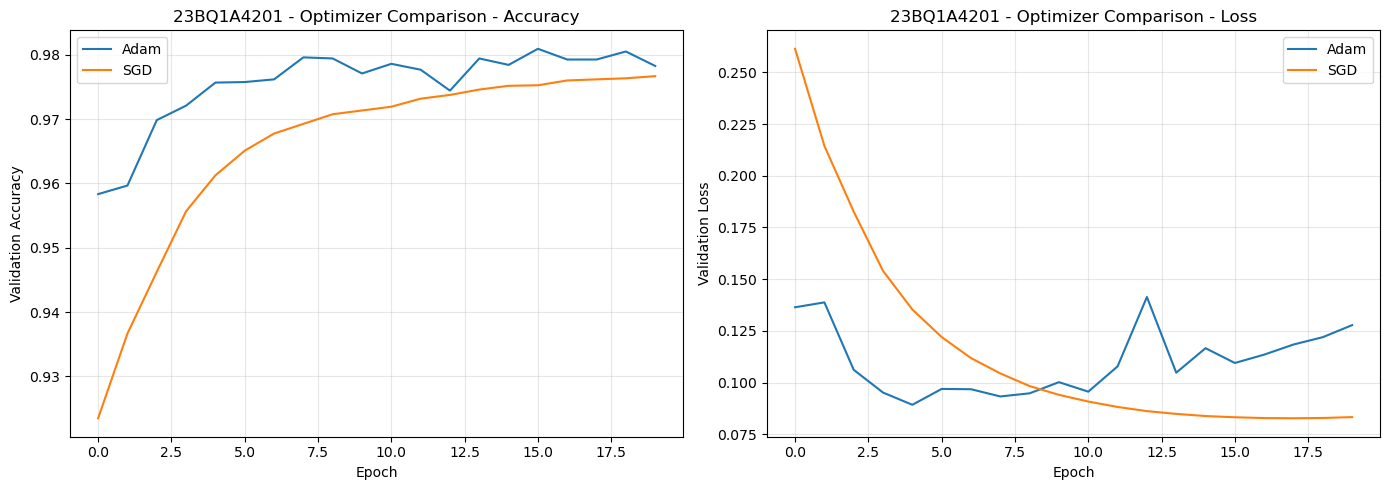

In [11]:
# Adam optimizer
model_adam = create_baseline_model()
model_adam.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

history_adam = model_adam.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)

# SGD optimizer
model_sgd = create_baseline_model()
model_sgd.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

history_sgd = model_sgd.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)

_, acc_adam = model_adam.evaluate(X_test_norm, y_test_encoded, verbose=0)
_, acc_sgd = model_sgd.evaluate(X_test_norm, y_test_encoded, verbose=0)

print(f"Adam Optimizer Test Accuracy: {acc_adam*100:.2f}%")
print(f"SGD Optimizer Test Accuracy: {acc_sgd*100:.2f}%")

# Plot optimizer comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_adam.history['val_accuracy'], label='Adam')
axes[0].plot(history_sgd.history['val_accuracy'], label='SGD')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('23BQ1A4201 - Optimizer Comparison - Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_adam.history['val_loss'], label='Adam')
axes[1].plot(history_sgd.history['val_loss'], label='SGD')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('23BQ1A4201 - Optimizer Comparison - Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10: Comprehensive Results Summary

In [12]:
# Build summary table from collected results
results_summary = pd.DataFrame({
    'Model': [
        'Baseline (2 layers)',
        'Deep (4 layers)',
        'No Dropout (Overfitting)',
        'With Dropout',
        'With L2',
        'Full Regularization',
        'Adam Optimizer',
        'SGD Optimizer'
    ],
    'Test Accuracy (%)': [
        test_accuracy * 100,
        test_accuracy_deep * 100,
        overfit_accuracy * 100,
        dropout_accuracy * 100,
        l2_accuracy * 100,
        test_accuracy_reg * 100,
        acc_adam * 100,
        acc_sgd * 100
    ],
    'Parameters': [
        baseline_model.count_params(),
        deep_model.count_params(),
        overfit_model.count_params(),
        dropout_model.count_params(),
        l2_model.count_params(),
        reg_model.count_params(),
        model_adam.count_params(),
        model_sgd.count_params()
    ]
})

print('='*72)
print('COMPREHENSIVE RESULTS SUMMARY')
print('='*72)
print(results_summary.to_string(index=False))
print('='*72)

best_accuracy = results_summary['Test Accuracy (%)'].max()
best_model_name = results_summary.loc[results_summary['Test Accuracy (%)'].idxmax(), 'Model']

print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {best_accuracy:.2f}%")

COMPREHENSIVE RESULTS SUMMARY
                   Model  Test Accuracy (%)  Parameters
     Baseline (2 layers)          98.140001      535818
         Deep (4 layers)          98.030001      575050
No Dropout (Overfitting)          98.310000     1462538
            With Dropout          98.229998      567434
                 With L2          97.570002      567434
     Full Regularization          97.539997      567434
          Adam Optimizer          97.930002      535818
           SGD Optimizer          97.979999      535818

Best Model: No Dropout (Overfitting)
Best Accuracy: 98.31%


In [13]:
# Quick helper prints for analysis question references
print(f"Baseline total parameters (manual): {total_params:,}")
print(f"Deep model parameters: {deep_model.count_params():,}")
print(f"Best model from summary: {best_model_name}")
print(f"Best accuracy achieved: {best_accuracy:.2f}%")

Baseline total parameters (manual): 535,818
Deep model parameters: 575,050
Best model from summary: No Dropout (Overfitting)
Best accuracy achieved: 98.31%
